# Projet de sélection — Exploration de données avec Python
### Parcours Développement en Intelligence Artificielle — YouCode

**Contexte :** L'entreprise **Sell4All** (vente de vêtements d'occasion en ligne) souhaite préparer une future fonctionnalité de recommandation de produits basée sur l'IA. Avant cela, je dois explorer et nettoyer les données clients disponibles dans `dataset-sell4all.csv`.

**Auteur :** Aouatif Cherdid

## 1. Import des bibliothèques

In [100]:
import pandas as pd 
import matplotlib.pyplot as plt

## 2. Lecture du fichier CSV

On charge le fichier `dataset-sell4all.csv` qui contient les données démographiques et les dépenses des clients.

In [101]:
df=pd.read_csv("dataset-sell4all.csv")

### Aperçu des 5 premières lignes

In [102]:
df.head()

,Name,Phone Number,Email,Address,Country,Postal code,Last date of connection,Last time of connection,Age,Gender,Customer spendings
0,Aaron Cote,966-7625,elit@hotmail.org,699-5837 Risus Street,Norway,4126,5-Apr-21,4:39,71,Man,356
1,Angelica Lawson,232-3051,diam.proin@google.org,481-8428 Magna. Street,Pakistan,518885,"oct. 10, 2021",0:36,37,Women,173
2,Louis Gilbert,1-997-733-0134,lorem.fringilla@hotmail.org,Ap #192-2082 Enim. Ave,Colombia,575444,2-Jul-22,3:37,24,Women,105
3,Basia Finley,1-987-322-7148,tristique.aliquet@icloud.co,608-2732 Nec Rd.,South Africa,5973-5765,19-Feb-22,2:34,37,Women,28
4,Rhona Sears,387-7682,iaculis.odio.nam@protonmail.org,8763 In Rd.,France,37476,31-Mar-22,6:28,42,Women,13


## 3. Résumé technique du jeu de données

On utilise `.info()` pour obtenir :
- le nombre d'entrées (lignes) du dataset,
- la liste des colonnes,
- le nombre de valeurs non nulles par colonne,
- le type de données de chaque colonne.

In [103]:
df.shape

(505, 11)

df.columns

In [104]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Name                     505 non-null    str  
 1   Phone Number             505 non-null    str  
 2   Email                    505 non-null    str  
 3   Address                  505 non-null    str  
 4   Country                  505 non-null    str  
 5   Postal code              505 non-null    str  
 6   Last date of connection  505 non-null    str  
 7   Last time of connection  505 non-null    str  
 8   Age                      505 non-null    int64
 9   Gender                   505 non-null    str  
 10  Customer spendings       505 non-null    int64
dtypes: int64(2), str(9)
memory usage: 43.5 KB


### Explication du résumé technique

**Combien y a-t-il d'entrées dans l'ensemble de données ?**
Le nombre total de lignes (entrées) est indiqué en haut du résultat de `.info()`, sous la forme `RangeIndex: X entries`. Dans notre cas, cela correspond au nombre total de clients enregistrés dans le fichier CSV, doublons compris (ils seront supprimés plus loin).

**Qu'est-ce que « non-null » (non nul) ?**
La colonne `Non-Null Count` indique, pour chaque colonne du dataset, le nombre de valeurs réellement renseignées (donc différentes de `NaN` / valeur manquante). Si ce nombre est inférieur au nombre total d'entrées, cela signifie qu'il manque des valeurs pour cette colonne (par exemple des âges non renseignés). C'est un indicateur essentiel de la qualité des données avant de les utiliser dans un projet d'IA.

**Quels types de données sont présents dans l'ensemble de données ? Quels sont ces types ?**
La colonne `Dtype` précise le type de chaque colonne :
- `int64` : nombres entiers (ex : identifiant client),
- `float64` : nombres décimaux, aussi utilisé quand une colonne numérique contient des valeurs manquantes (ex : Age, Customer spendings),
- `object` : texte / chaînes de caractères (ex : Country, Gender).

Comprendre ces types est indispensable car certaines opérations (calculs statistiques, encodage pour un modèle d'IA) ne sont possibles que sur des types numériques.

## 4. Statistiques descriptives : médiane et moyenne

Calcul de la médiane et de la moyenne des colonnes `Age` et `Customer spendings`.

In [105]:
age_mean = df['Age'].mean()
age_median = df['Age'].median()
spendings_mean = df['Customer spendings'].mean()
spendings_median = df['Customer spendings'].median()

print(f"Age -> moyenne : {age_mean:.2f} ans | médiane : {age_median:.2f} ans")
print(f"Customer spendings -> moyenne : {spendings_mean:.2f} € | médiane : {spendings_median:.2f} €")


Age -> moyenne : 46.08 ans | médiane : 46.00 ans
Customer spendings -> moyenne : 311.17 € | médiane : 307.00 €


**Interprétation :** la moyenne est sensible aux valeurs extrêmes (ex : un client qui dépense énormément fait remonter la moyenne des dépenses), alors que la médiane représente la valeur centrale réelle, moins influencée par ces extrêmes. Comparer les deux permet de détecter une distribution asymétrique dans les dépenses clients.

## 5. Question bonus : médiane d'âge par pays

On regroupe les données par pays (`groupby`) et on calcule la médiane de l'âge pour chaque groupe.

In [106]:
median_age_per_country = df.groupby('Country')['Age'].median().sort_values(ascending=False)
median_age_per_country


Country
Turkey                60.0
France                56.5
Spain                 54.5
Norway                54.0
Germany               53.0
Philippines           51.0
Brazil                49.5
South Korea           49.5
Poland                49.5
Ireland               49.0
United States         48.5
United Kingdom        48.5
Netherlands           48.0
Vietnam               48.0
Costa Rica            48.0
Russian Federation    48.0
Mexico                47.0
Ukraine               46.0
Canada                46.0
Chile                 46.0
India                 45.5
Australia             44.0
Pakistan              44.0
South Africa          43.0
Austria               43.0
Singapore             41.5
Indonesia             41.5
Italy                 41.0
Sweden                40.0
Belgium               39.0
New Zealand           38.0
Peru                  38.0
Nigeria               37.0
China                 35.0
Colombia              29.0
Name: Age, dtype: float64

## 6. Visualisation : dépenses des clients par pays

Un graphique à barres montrant la somme des dépenses des clients (`Customer spendings`) par pays.

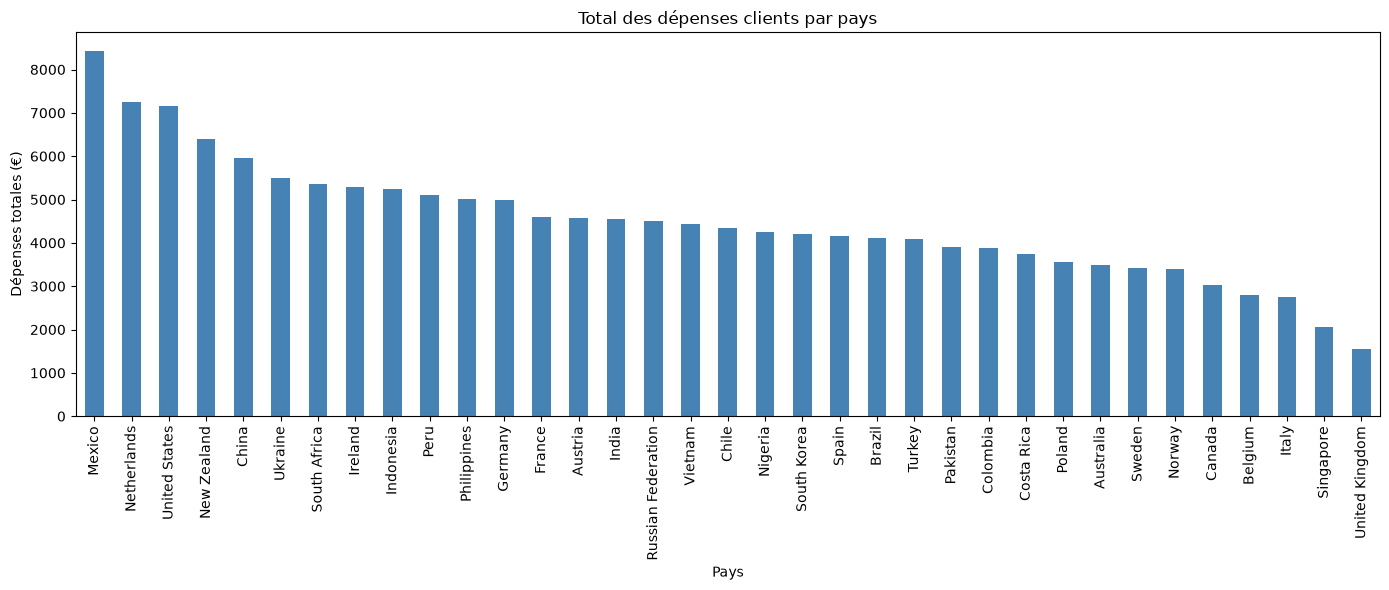

In [107]:
plt.figure(figsize=(14,6))  # plus large au lieu de (9,5)
spendings_per_country.plot(kind='bar', color='steelblue')
plt.title("Total des dépenses clients par pays")
plt.xlabel("Pays")
plt.ylabel("Dépenses totales (€)")
plt.xticks(rotation=90)  # rotation à 90° au lieu de 45°
plt.tight_layout()
plt.show()

## 7. Nettoyage des données

### 7.1 Suppression des lignes avec moins de 10 € de dépenses
On supprime toutes les lignes des clients ayant dépensé moins de 10 € sur le site (ces clients ne sont pas pertinents pour un futur système de recommandation basé sur les habitudes d'achat).

In [108]:
nb_avant = len(df)
df = df[df['Customer spendings'] >= 10]
nb_apres = len(df)
print(f"Lignes supprimées (dépenses < 10€) : {nb_avant - nb_apres}")


Lignes supprimées (dépenses < 10€) : 3


### 7.2 Suppression des doublons
On supprime toutes les lignes qui apparaissent plus d'une fois dans les données.

In [109]:
nb_avant = len(df)
df = df.drop_duplicates()
nb_apres = len(df)
print(f"Lignes en double supprimées : {nb_avant - nb_apres}")


Lignes en double supprimées : 5


### 7.3 Vérification finale

In [110]:
print(f"Nombre de lignes après nettoyage : {len(df)}")
df.head()


Nombre de lignes après nettoyage : 497


,Name,Phone Number,Email,Address,Country,Postal code,Last date of connection,Last time of connection,Age,Gender,Customer spendings
0,Aaron Cote,966-7625,elit@hotmail.org,699-5837 Risus Street,Norway,4126,5-Apr-21,4:39,71,Man,356
1,Angelica Lawson,232-3051,diam.proin@google.org,481-8428 Magna. Street,Pakistan,518885,"oct. 10, 2021",0:36,37,Women,173
2,Louis Gilbert,1-997-733-0134,lorem.fringilla@hotmail.org,Ap #192-2082 Enim. Ave,Colombia,575444,2-Jul-22,3:37,24,Women,105
3,Basia Finley,1-987-322-7148,tristique.aliquet@icloud.co,608-2732 Nec Rd.,South Africa,5973-5765,19-Feb-22,2:34,37,Women,28
4,Rhona Sears,387-7682,iaculis.odio.nam@protonmail.org,8763 In Rd.,France,37476,31-Mar-22,6:28,42,Women,13


## 8. Export du fichier nettoyé

On écrit les données nettoyées dans un nouveau fichier CSV en ne gardant que les colonnes : `Country`, `Âge`, `Gender`, `Customer spendings`.

In [111]:
df_clean = df[['Country', 'Age', 'Gender', 'Customer spendings']].copy()
df_clean = df_clean.rename(columns={'Age': 'Âge'})

df_clean.to_csv('dataset-sell4all-clean.csv', index=False)
df_clean.head()


,Country,Âge,Gender,Customer spendings
0,Norway,71,Man,356
1,Pakistan,37,Women,173
2,Colombia,24,Women,105
3,South Africa,37,Women,28
4,France,42,Women,13
